In [ ]:
import os
import sys

# Repository root, so that paths.py (DATA_DIR / RESULTS_DIR / FIGURES_DIR) can be imported.
sys.path.insert(0, os.path.abspath('../..'))
import paths

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

import sherlock as slk

In [2]:
concentration = 10000

In [3]:
# UPLOAD DATA 

data = sc.read_mtx(
    f'{paths.DATA_DIR}/gbm/egfr/BT333_EGFRi_cds_count_matrix_transposed.mtx')

row = pd.read_csv(f"{paths.DATA_DIR}/gbm/egfr/BT333_EGFRi_cds_rowData.csv",
                       sep=',')

col = pd.read_csv(f"{paths.DATA_DIR}/gbm/egfr/BT333_EGFRi_cds_colData.csv",
                       sep=',')



In [4]:
row

,id,gene_short_name,num_cells_expressed
0,ENSG00000000003.14,TSPAN6,3111
1,ENSG00000000419.12,DPM1,4673
2,ENSG00000000457.13,SCYL3,1774
3,ENSG00000000460.16,C1orf112,3169
4,ENSG00000001036.13,FUCA2,7313
...,...,...,...
10427,ENSG00000283977.1,AC084337.2,2546
10428,ENSG00000284057.1,AP001273.2,830
10429,ENSG00000284292.1,AC004922.1,2585
10430,ENSG00000284461.1,RABGEF1,3325


In [5]:
col

,P7,P5,sample,Size_Factor,n_umi,cell_ID,RT,Lig,RT_well_position,cell_line,...,top_to_second_best_ratio,log10_dose,Cell,log10_umi,percent_mito,doublet_score,num_genes_expressed,g1s_score,g2m_score,proliferation_index
0,01D,A04,1,8.052607,10718,01D_A04_RT_BC_105_Lig_BC_129,RT_BC_105,Lig_BC_129,A09,BT333,...,21.200000,2.0,01D_A04_RT_BC_105_Lig_BC_129,4.030114,0.0,0.025488,4806,1.248086,2.856022,2.989507
1,01D,A04,1,1.441776,1919,01D_A04_RT_BC_105_Lig_BC_144,RT_BC_105,Lig_BC_144,A09,BT333,...,21.285714,-inf,01D_A04_RT_BC_105_Lig_BC_144,3.283075,0.0,0.036003,1396,0.000000,1.125179,1.125179
2,01D,A04,1,5.458312,7265,01D_A04_RT_BC_105_Lig_BC_147,RT_BC_105,Lig_BC_147,A09,BT333,...,4.677419,2.0,01D_A04_RT_BC_105_Lig_BC_147,3.861236,0.0,0.040030,3953,1.578431,2.437360,2.727208
3,01D,A04,1,1.978215,2633,01D_A04_RT_BC_105_Lig_BC_166,RT_BC_105,Lig_BC_166,A09,BT333,...,131.000000,1.0,01D_A04_RT_BC_105_Lig_BC_166,3.420451,0.0,0.023551,1784,0.000000,1.618209,1.618209
4,01D,A04,1,3.208120,4270,01D_A04_RT_BC_105_Lig_BC_21,RT_BC_105,Lig_BC_21,A09,BT333,...,2.739130,2.0,01D_A04_RT_BC_105_Lig_BC_21,3.630428,0.0,0.041979,2786,1.250953,2.450842,2.645592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53205,12C,H04,2,3.250194,4326,12C_H04_RT_BC_192_Lig_BC_64,RT_BC_192,Lig_BC_64,H12,BT333,...,31.333333,3.0,12C_H04_RT_BC_192_Lig_BC_64,3.636087,0.0,0.111968,2689,0.802314,0.802314,1.241671
53206,12C,H04,2,2.090913,2783,12C_H04_RT_BC_192_Lig_BC_75,RT_BC_192,Lig_BC_75,H12,BT333,...,12.750000,4.0,12C_H04_RT_BC_192_Lig_BC_75,3.444513,0.0,0.016546,1931,1.353141,1.069197,1.754853
53207,12C,H04,2,2.929382,3899,12C_H04_RT_BC_192_Lig_BC_79,RT_BC_192,Lig_BC_79,H12,BT333,...,7.142857,4.0,12C_H04_RT_BC_192_Lig_BC_79,3.590953,0.0,0.025991,2580,2.290066,1.865924,2.730301
53208,12C,H04,2,2.873784,3825,12C_H04_RT_BC_192_Lig_BC_93,RT_BC_192,Lig_BC_93,H12,BT333,...,62.000000,1.0,12C_H04_RT_BC_192_Lig_BC_93,3.582631,0.0,0.042378,2434,0.872085,1.499563,1.770131


In [6]:
# Check for duplicate gene names
print(f"Are var names unique? {data.var_names.is_unique}")

if not data.var_names.is_unique:
    print("Making var names unique...")
    data.var_names_make_unique()
    print(f"Are var names unique now? {data.var_names.is_unique}")

Are var names unique? True


In [7]:
data

AnnData object with n_obs × n_vars = 53210 × 10432

In [8]:
# Assemble AnnData
# Check dimensions to determine orientation
print(f"Initial adata shape: {data.shape}")
print(f"Row data (genes): {len(row)}")
print(f"Col data (cells): {len(col)}")

# Transpose if necessary to get (cells x genes)
# If rows of matrix match rows of rowData (genes), then it's (genes x cells) -> Transpose
if data.shape[0] == len(row):
    print("Transposing adata...")
    data = data.T

# Verify dimensions match before assignment
if data.shape[0] != len(col) or data.shape[1] != len(row):
    print("WARNING: Dimensions do not match!")
    print(f"Expected ({len(col)}, {len(row)}) but got {data.shape}")
else:
    # Assign metadata
    data.obs = col
    data.var = row
    
    # Handle indices (often 'Unnamed: 0' from CSVs)
    if 'Unnamed: 0' in data.obs.columns:
        data.obs = data.obs.set_index('Unnamed: 0')
        data.obs.index.name = None
    
    if 'Unnamed: 0' in data.var.columns:
        data.var = data.var.set_index('Unnamed: 0')
        data.var.index.name = None
        
    print("AnnData assembled successfully.")

data

Initial adata shape: (53210, 10432)
Row data (genes): 10432
Col data (cells): 53210
AnnData assembled successfully.


AnnData object with n_obs × n_vars = 53210 × 10432
    obs: 'P7', 'P5', 'sample', 'Size_Factor', 'n_umi', 'cell_ID', 'RT', 'Lig', 'RT_well_position', 'cell_line', 'replicate', 'drug', 'dose', 'hash_plate', 'hash_well', 'hash_umis', 'proportion', 'total_hash_umis_per_cell', 'rank', 'top_to_second_best_ratio', 'log10_dose', 'Cell', 'log10_umi', 'percent_mito', 'doublet_score', 'num_genes_expressed', 'g1s_score', 'g2m_score', 'proliferation_index'
    var: 'id', 'gene_short_name', 'num_cells_expressed'

In [9]:
data = data[(data.obs['hash_umis']>10) & (data.obs['top_to_second_best_ratio']>5)].copy()

/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [10]:
data

AnnData object with n_obs × n_vars = 45849 × 10432
    obs: 'P7', 'P5', 'sample', 'Size_Factor', 'n_umi', 'cell_ID', 'RT', 'Lig', 'RT_well_position', 'cell_line', 'replicate', 'drug', 'dose', 'hash_plate', 'hash_well', 'hash_umis', 'proportion', 'total_hash_umis_per_cell', 'rank', 'top_to_second_best_ratio', 'log10_dose', 'Cell', 'log10_umi', 'percent_mito', 'doublet_score', 'num_genes_expressed', 'g1s_score', 'g2m_score', 'proliferation_index'
    var: 'id', 'gene_short_name', 'num_cells_expressed'

In [11]:
data.var.index = data.var['gene_short_name']

In [12]:
data = data[data.obs['n_umi' ]>100].copy()
data

/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 45849 × 10432
    obs: 'P7', 'P5', 'sample', 'Size_Factor', 'n_umi', 'cell_ID', 'RT', 'Lig', 'RT_well_position', 'cell_line', 'replicate', 'drug', 'dose', 'hash_plate', 'hash_well', 'hash_umis', 'proportion', 'total_hash_umis_per_cell', 'rank', 'top_to_second_best_ratio', 'log10_dose', 'Cell', 'log10_umi', 'percent_mito', 'doublet_score', 'num_genes_expressed', 'g1s_score', 'g2m_score', 'proliferation_index'
    var: 'id', 'gene_short_name', 'num_cells_expressed'

In [13]:
data.obs[['drug', 'dose']]

,drug,dose
0,Alflutinib,100
1,DMSO,0
3,EAI045,10
5,EAI045,100
7,NSC228155,1000
...,...,...
53205,PD168393,1000
53206,TAS6417,10000
53207,PD153035,10000
53208,AG555,10


In [14]:
print(data.obs['drug'].unique().tolist())

['Alflutinib', 'DMSO', 'EAI045', 'NSC228155', 'AEE788', 'CL-387785', 'Ibrutinib', 'PD168393', 'HER2-Inhibitor-1', 'ChrysophanicAcid', 'Daphnetin', 'AZD3759', 'TyrphostinAG-528', 'Allitinib', 'Poziotinib', 'Lifirafenib', 'AP26113-analog', 'WZ4002', 'BDTX-189', 'Irbinitinib', 'PBS', 'Icotinib', 'Nazartinib', 'Gefitinib-PROTAC3', 'AG99', 'AG-1478', 'MTX-211', 'AG555', 'Brigatinib', 'TAS6417', 'Puromycin', 'HS-10296', 'Dacomitinib', 'Lapatinib', 'Naquotinib', 'SU5214', 'EGFRInhibitor', 'Osimertinib', 'WZ8040', 'WZ3146', 'AZ5104', 'CNX-2006', 'Media', 'Epigallocatechin-Gallate', 'AG494', 'TAK-285', 'Varlitinib', 'Olmutinib', 'Sapitinib', 'Afatinib', 'OSI-420', 'EBE-A22', 'WHI-P154', 'Panitumumab', 'DZD9008', 'AG-490', 'CUDC-101', 'RG13022', 'Norcantharidin', 'Mobocertinib', 'Tyrphostin9', 'Avitinib', 'Rociletinib', 'AC480', 'Genistein', 'CP-724714', 'PD153035', 'Cyasterone', 'Pelitinib', 'JBJ-04-125-02', 'Lidocaine', 'Saracatinib', 'Neratinib', 'AG-1557', 'Gefitinib', 'Butein', 'AG-18']


In [15]:
# Select only concentration of 1 from all drugs and add DMSO control
control_data = data[
    (data.obs['dose'] == concentration) | (data.obs['drug'].isin(['DMSO']))
].copy()

/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [16]:
# filter for drugs has more than 100 cells
drug_counts = control_data.obs['drug'].value_counts()
drugs_to_keep = drug_counts[drug_counts > 100].index
control_data = control_data[control_data.obs['drug'].isin(drugs_to_keep)].copy()

print(f"Kept {len(drugs_to_keep)} drugs with > 100 cells.")
print(control_data.obs['drug'].value_counts())

Kept 50 drugs with > 100 cells.
drug
DMSO                        4464
Allitinib                    354
Cyasterone                   177
AG555                        173
AG-490                       164
HER2-Inhibitor-1             162
Nazartinib                   161
EBE-A22                      160
Genistein                    156
SU5214                       154
Varlitinib                   154
Icotinib                     154
BDTX-189                     153
AG99                         153
EAI045                       151
CP-724714                    151
Lidocaine                    151
JBJ-04-125-02                150
AC480                        149
Lapatinib                    145
Norcantharidin               144
TAS6417                      143
Neratinib                    143
Lifirafenib                  143
Irbinitinib                  141
TyrphostinAG-528             140
PD153035                     137
PD168393                     137
Afatinib                     134
RG1302

/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [17]:
control_data

AnnData object with n_obs × n_vars = 11420 × 10432
    obs: 'P7', 'P5', 'sample', 'Size_Factor', 'n_umi', 'cell_ID', 'RT', 'Lig', 'RT_well_position', 'cell_line', 'replicate', 'drug', 'dose', 'hash_plate', 'hash_well', 'hash_umis', 'proportion', 'total_hash_umis_per_cell', 'rank', 'top_to_second_best_ratio', 'log10_dose', 'Cell', 'log10_umi', 'percent_mito', 'doublet_score', 'num_genes_expressed', 'g1s_score', 'g2m_score', 'proliferation_index'
    var: 'id', 'gene_short_name', 'num_cells_expressed'

In [18]:
control_data.obs['drug'].value_counts()

drug
DMSO                        4464
Allitinib                    354
Cyasterone                   177
AG555                        173
AG-490                       164
HER2-Inhibitor-1             162
Nazartinib                   161
EBE-A22                      160
Genistein                    156
SU5214                       154
Varlitinib                   154
Icotinib                     154
BDTX-189                     153
AG99                         153
EAI045                       151
CP-724714                    151
Lidocaine                    151
JBJ-04-125-02                150
AC480                        149
Lapatinib                    145
Norcantharidin               144
TAS6417                      143
Neratinib                    143
Lifirafenib                  143
Irbinitinib                  141
TyrphostinAG-528             140
PD153035                     137
PD168393                     137
Afatinib                     134
RG13022                      133
OSI-4

In [19]:
data

AnnData object with n_obs × n_vars = 45849 × 10432
    obs: 'P7', 'P5', 'sample', 'Size_Factor', 'n_umi', 'cell_ID', 'RT', 'Lig', 'RT_well_position', 'cell_line', 'replicate', 'drug', 'dose', 'hash_plate', 'hash_well', 'hash_umis', 'proportion', 'total_hash_umis_per_cell', 'rank', 'top_to_second_best_ratio', 'log10_dose', 'Cell', 'log10_umi', 'percent_mito', 'doublet_score', 'num_genes_expressed', 'g1s_score', 'g2m_score', 'proliferation_index'
    var: 'id', 'gene_short_name', 'num_cells_expressed'

In [20]:
control_data

AnnData object with n_obs × n_vars = 11420 × 10432
    obs: 'P7', 'P5', 'sample', 'Size_Factor', 'n_umi', 'cell_ID', 'RT', 'Lig', 'RT_well_position', 'cell_line', 'replicate', 'drug', 'dose', 'hash_plate', 'hash_well', 'hash_umis', 'proportion', 'total_hash_umis_per_cell', 'rank', 'top_to_second_best_ratio', 'log10_dose', 'Cell', 'log10_umi', 'percent_mito', 'doublet_score', 'num_genes_expressed', 'g1s_score', 'g2m_score', 'proliferation_index'
    var: 'id', 'gene_short_name', 'num_cells_expressed'

In [21]:
control_data.obs['drug'].unique()

array(['DMSO', 'Allitinib', 'Ibrutinib', 'Daphnetin', 'WZ4002', 'AG555',
       'SU5214', 'AG99', 'TyrphostinAG-528', 'PD168393', 'Poziotinib',
       'TAS6417', 'Epigallocatechin-Gallate', 'Varlitinib', 'OSI-420',
       'Nazartinib', 'WHI-P154', 'HER2-Inhibitor-1', 'DZD9008',
       'Lapatinib', 'EBE-A22', 'Genistein', 'Lifirafenib', 'Afatinib',
       'Norcantharidin', 'AC480', 'EAI045', 'Olmutinib', 'PD153035',
       'CUDC-101', 'BDTX-189', 'AG-1557', 'Gefitinib', 'Neratinib',
       'AG-490', 'Dacomitinib', 'Cyasterone', 'Irbinitinib',
       'Tyrphostin9', 'Butein', 'CP-724714', 'Icotinib', 'RG13022',
       'ChrysophanicAcid', 'Pelitinib', 'Lidocaine', 'Avitinib', 'AG494',
       'JBJ-04-125-02', 'AG-18'], dtype=object)

In [22]:
sc.pp.normalize_total(control_data)
sc.pp.log1p(control_data)
sc.pp.pca(control_data)

sc.tl.rank_genes_groups(
    control_data, groupby='drug', reference='DMSO',
    use_raw=False, method='wilcoxon'
)

/home/user/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/user/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/user/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: PerformanceWarning: DataFrame is highly fragmente

In [23]:
# Long-form results across all groups
df = sc.get.rank_genes_groups_df(control_data, group=None, key='rank_genes_groups')

# Raw p-value < 0.05
sig_raw = (df.loc[df['pvals'] < 0.05]
             .sort_values(['group','pvals'])
             .reset_index(drop=True))

# Adjusted p-value (FDR) < 0.05 (recommended)
sig_adj = (df.loc[df['pvals_adj'] < 0.05]
             .sort_values(['group','pvals_adj'])
             .reset_index(drop=True))

# Per-group lists (raw p)
deg_by_group_raw = (sig_raw.groupby('group')['names'].apply(list).to_dict())

# Per-group lists (FDR)
deg_by_group_adj = (sig_adj.groupby('group')['names'].apply(list).to_dict())

# Unique gene sets
unique_deg_raw = sorted(sig_raw['names'].unique().tolist())
unique_deg_adj = sorted(sig_adj['names'].unique().tolist())

print("\nCounts (FDR<0.05) per group:")
print(sig_adj.groupby('group').size())


Counts (FDR<0.05) per group:
group
AC480                         1
AG99                          3
AG494                         9
AG555                         5
AG-18                         0
AG-490                        4
AG-1557                      16
Afatinib                     15
Allitinib                    31
Avitinib                     42
BDTX-189                     38
Butein                        8
CP-724714                     0
CUDC-101                    902
ChrysophanicAcid              0
Cyasterone                    0
DZD9008                      51
Dacomitinib                  14
Daphnetin                     0
EAI045                        0
EBE-A22                       1
Epigallocatechin-Gallate      0
Gefitinib                    46
Genistein                     0
HER2-Inhibitor-1              2
Ibrutinib                    84
Icotinib                      0
Irbinitinib                   0
JBJ-04-125-02                 2
Lapatinib                     3
Lido

/tmp/ipykernel_1302979/3292257313.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deg_by_group_raw = (sig_raw.groupby('group')['names'].apply(list).to_dict())
/tmp/ipykernel_1302979/3292257313.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deg_by_group_adj = (sig_adj.groupby('group')['names'].apply(list).to_dict())
/tmp/ipykernel_1302979/3292257313.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sig

In [24]:
df

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,AC480,GPM6B,3.874619,0.463124,0.000107,0.123783
1,AC480,TMTC2,3.291328,0.737801,0.000997,0.520116
2,AC480,CUX1,3.222138,0.614448,0.001272,0.625598
3,AC480,PTPRZ1,3.199283,0.406655,0.001378,0.625598
4,AC480,SCD,3.187714,0.647494,0.001434,0.625598
...,...,...,...,...,...,...
511163,WZ4002,KPNB1,-2.885573,-0.506119,0.003907,0.999931
511164,WZ4002,CYCS,-2.921864,-1.025824,0.003479,0.999931
511165,WZ4002,XPO1,-2.930799,-0.816864,0.003381,0.999931
511166,WZ4002,GAP43,-3.391406,-0.674069,0.000695,0.999931


In [25]:
deg_genes = df[df['pvals_adj'] < 0.05]['names'].unique()

In [26]:
deg_genes

array(['TUBA1B', 'HSP90B1', 'PXDN', ..., 'HIP1', 'MTATP6P1', 'ARNTL2'],
      dtype=object)

In [27]:
# make sets (cast to str to avoid dtype issues)

deg_set = set(map(str, deg_genes))
union_set = deg_set
union_list = sorted(union_set)

print(f"deg_genes:        {len(deg_set)} genes")
print(f"union:            {len(union_set)} genes")

deg_genes:        1157 genes
union:            1157 genes


In [27]:
data

AnnData object with n_obs × n_vars = 45849 × 10432
    obs: 'P7', 'P5', 'sample', 'Size_Factor', 'n_umi', 'cell_ID', 'RT', 'Lig', 'RT_well_position', 'cell_line', 'replicate', 'drug', 'dose', 'hash_plate', 'hash_well', 'hash_umis', 'proportion', 'total_hash_umis_per_cell', 'rank', 'top_to_second_best_ratio', 'log10_dose', 'Cell', 'log10_umi', 'percent_mito', 'doublet_score', 'num_genes_expressed', 'g1s_score', 'g2m_score', 'proliferation_index'
    var: 'id', 'gene_short_name', 'num_cells_expressed'

In [28]:
data.var

,id,gene_short_name,num_cells_expressed
gene_short_name,,,
TSPAN6,ENSG00000000003.14,TSPAN6,3111
DPM1,ENSG00000000419.12,DPM1,4673
SCYL3,ENSG00000000457.13,SCYL3,1774
C1orf112,ENSG00000000460.16,C1orf112,3169
FUCA2,ENSG00000001036.13,FUCA2,7313
...,...,...,...
AC084337.2,ENSG00000283977.1,AC084337.2,2546
AP001273.2,ENSG00000284057.1,AP001273.2,830
AC004922.1,ENSG00000284292.1,AC004922.1,2585


In [28]:
data.X.max()

1142.0

In [29]:
len(union_list)

1157

In [30]:
# Ensure gene names are unique before slicing
# (Setting data.var.index = data.var['gene_short_name'] earlier may have introduced duplicates)
if not data.var_names.is_unique:
    print(f"Duplicate var_names found: {data.var_names.is_unique}")
    data.var_names_make_unique()
    print("Made var_names unique.")

# Also ensure we only request genes that actually exist in the data
# (In case some DEGs were filtered out or renamed)
valid_genes = [g for g in union_list if g in data.var_names]
print(f"Requested genes: {len(union_list)}")
print(f"Valid genes found in data: {len(valid_genes)}")

union_list = valid_genes

Duplicate var_names found: False
Made var_names unique.
Requested genes: 1157
Valid genes found in data: 1157


In [31]:
data = data[:, union_list].copy()

In [32]:
data.write_h5ad(f"{paths.DATA_DIR}/gbm/bt333_egfr_degs_{concentration}.h5ad")

In [69]:
data.shape

(45849, 245)

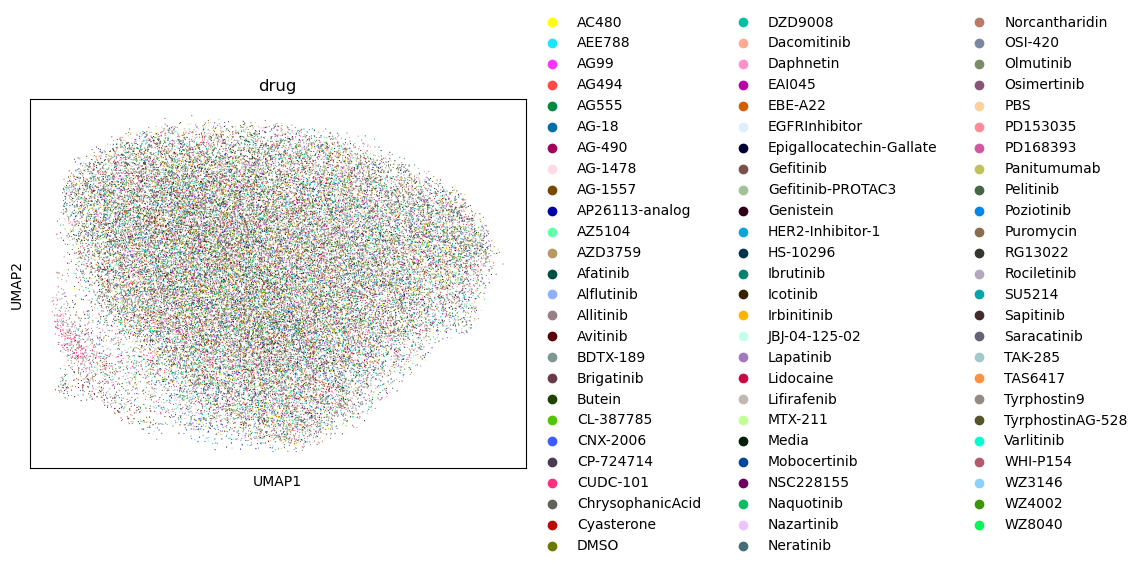

In [70]:
sc.pp.normalize_total(data)
sc.pp.log1p(data)
sc.pp.pca(data)

sc.pp.neighbors(data)
sc.tl.umap(data)
sc.pl.umap(data, color=['drug'])